## Plan

This jupyter notebook breaks down the flow of using OCHRE for building 
envelope system identification

In [2]:
#function needed:
import pandas as pd

def attach_epw_to_df(df, epw_path,
                     keep_cols=("Dry Bulb (C)",
                                "Relative Humidity (%)",
                                "Global Horizontal Radiation (Wh/m^2)",
                                "Wind Speed (m/s)"),
                     out_names=("Temperature - Outdoor (C) [EPW]",
                                "Relative Humidity - Outdoor (%) [EPW]",
                                "Global Horizontal Irradiance (W/m^2) [EPW]",  # EPW is Wh/m² (hourly avg)
                                "Wind Speed - Outdoor (m/s) [EPW]")):
    # --- read EPW ---
    cols = [
        "Year","Month","Day","Hour","Minute","Flags",
        "Dry Bulb (C)","Dew Point (C)","Relative Humidity (%)","Atmos Pressure (Pa)",
        "Extraterrestrial Horizontal Radiation (Wh/m^2)",
        "Extraterrestrial Direct Normal Radiation (Wh/m^2)",
        "Horizontal IR Intensity (Wh/m^2)",
        "Global Horizontal Radiation (Wh/m^2)",
        "Direct Normal Radiation (Wh/m^2)",
        "Diffuse Horizontal Radiation (Wh/m^2)",
        "Global Horizontal Illuminance (lux)",
        "Direct Normal Illuminance (lux)",
        "Diffuse Horizontal Illuminance (lux)",
        "Zenith Luminance (Cd/m^2)",
        "Wind Direction (deg)","Wind Speed (m/s)","Total Sky Cover (tenths)",
        "Opaque Sky Cover (tenths)","Visibility (km)","Ceiling Height (m)",
        "Present Weather Observation","Present Weather Codes",
        "Precipitable Water (mm)","Aerosol Optical Depth (thousandths)",
        "Snow Depth (cm)","Days Since Last Snowfall",
        "Albedo","Liquid Precipitation Depth (mm)","Liquid Precipitation Quantity (hr)"
    ]
    epw = pd.read_csv(epw_path, skiprows=8, header=None, names=cols)

    # --- Build timestamp ignoring EPW 'Year' ---
    # EPW Hour = 1..24 marks END of hour → convert to start of hour
    h = epw["Hour"].to_numpy()
    carry = (h == 24).astype(int)
    hour0 = (h % 24)

    # choose a single year: the sim's year
    sim_year = int(df.index[0].year)

    dt = pd.to_datetime({
        "year": sim_year,                            # force a single year
        "month": epw["Month"],
        "day": epw["Day"],
        "hour": hour0,
        # EPW minute is usually 0 for hourly TMY; include if present
        "minute": epw["Minute"] if "Minute" in epw else 0
    })
    # shift hour=24 rows to next day (now within the same sim_year)
    dt = dt + pd.to_timedelta(carry, unit="D")

    wx = epw.set_index(dt)[list(keep_cols)].copy()
    wx.columns = list(out_names)

    # RH sanity
    if "Relative Humidity - Outdoor (%) [EPW]" in wx:
        wx["Relative Humidity - Outdoor (%) [EPW]"] = wx["Relative Humidity - Outdoor (%) [EPW]"].clip(0, 100)

    # Align to sim timeline; hourly → sub-hourly via forward-fill
    # If df has irregular start (e.g., not exactly at :00), also bfill edges.
    wx_aligned = wx.reindex(df.index, method="ffill").bfill()

    # Join
    out = df.join(wx_aligned, how="left")
    return out




## Step 1
Initialize the building and weather data. Note, how scheduling is also 
initialized, but this is for other power loads in the house (washer, dryer, 
etc.) 

In [3]:
import os
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ochre import CreateFigures
from ochre import Dwelling
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
default_input_path = os.path.join(PROJECT_ROOT, "ochre", "defaults")

timestep_sim = 1 # timestep of simulation in minutes

dwelling_args = {
    # Timing parameters
    "start_time": dt.datetime(2018, 1, 1, 0, 0),  # (year, month, day, hour, 
    # minute)
    "time_res": dt.timedelta(minutes=timestep_sim),         # time resolution
    # of the simulation
    "duration": dt.timedelta(days=1),             # duration of the 
    # simulation to just initialize. Will change later
    "verbosity": 6,

    # Input files
    "hpxml_file": os.path.join(default_input_path, "Input Files", 
                               "bldg0112631-up11.xml"),
    "hpxml_schedule_file": os.path.join(default_input_path, "Input Files", "bldg0112631_schedule.csv"),
    "weather_file": os.path.join(default_input_path, "Weather", "USA_CO_Denver.Intl.AP.725650_TMY3.epw"),
}

# Create Dwelling model
dwelling = Dwelling(**dwelling_args)
heater = dwelling.get_equipment_by_end_use("HVAC Heating")
schedule = heater.schedule
schedule["HVAC Heating Deadband (C)"] = 2
peak_times = (schedule.index.hour >= 10) & (schedule.index.hour < 15)
schedule.loc[peak_times, "HVAC Heating Setpoint (C)"] -= 3

heater.min_on_time = 600*2          # min cycle on for 
heater.min_off_time = 600*2         # min cycle off for

heater.reset_time()

df, metrics, hourly = dwelling.simulate()

2025-11-04 10:34:24.036454 - ochre at 2018-01-01 00:00:00: Initializing ochre (OCHRE v0.9.1)
2025-11-04 10:34:24.036700 - ochre at 2018-01-01 00:00:00: Removing previous results file: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre.csv
2025-11-04 10:34:24.041172 - ochre at 2018-01-01 00:00:00: Removing previous results file: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_metrics.csv
2025-11-04 10:34:24.041277 - ochre at 2018-01-01 00:00:00: Removing previous results file: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_hourly.csv
2025-11-04 10:34:24.041507 - ochre at 2018-01-01 00:00:00: Removing previous results file: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_schedule.csv
2025-11-04 10:34:25.523369 - ochre at 2018-01-01 00:00:00: Dwelling Initialized
2025-11-04 10:34:25.525193 - ochre at 2018-01-01 00:00:00: Running Simulation for 1 day, 0:00:00
2025-11-04 10:

In [4]:
dwelling

In [5]:
df.head()

,Total Electric Power (kW),Total Reactive Power (kVAR),Total Gas Power (therms/hour),Total Electric Energy (kWh),Total Reactive Energy (kVARh),Total Gas Energy (therms),HVAC Cooling Electric Power (kW),Lighting Electric Power (kW),Water Heating Electric Power (kW),Other Electric Power (kW),...,Temperature - Ground (C),Net Sensible Heat Gain - Indoor (W),Net Sensible Heat Gain - Foundation (W),Net Sensible Heat Gain - Garage (W),Net Sensible Heat Gain - Attic (W),Infiltration Heat Gain - Indoor (W),Forced Ventilation Heat Gain - Indoor (W),Natural Ventilation Heat Gain - Indoor (W),Internal Heat Gain - Indoor (W),Window Transmitted Solar Gain (W)
Time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,0.29796,0.187849,0.0,0.004966,0.003131,0.0,0.05,0.016273,0.001,0.230687,...,6.529479,-3234.197179,-3157.025931,-7240.811301,-310.210724,-3578.392666,-0.0,-0.0,365.640333,0.0
2018-01-01 00:01:00,0.29796,0.187849,0.0,0.004966,0.003131,0.0,0.05,0.016273,0.001,0.230687,...,6.529479,-3210.218689,-3079.732433,-7055.657737,-292.755506,-3560.331869,-0.0,-0.0,365.640333,0.0
2018-01-01 00:02:00,0.29796,0.187849,0.0,0.004966,0.003131,0.0,0.05,0.016273,0.001,0.230687,...,6.529479,-3187.425448,-3012.066928,-6887.029134,-290.824793,-3542.804981,-0.0,-0.0,365.640333,0.0
2018-01-01 00:03:00,0.29796,0.187849,0.0,0.004966,0.003131,0.0,0.05,0.016273,0.001,0.230687,...,6.529479,-3165.139969,-2948.488956,-6724.990990,-287.534525,-3525.788390,-0.0,-0.0,365.640333,0.0
2018-01-01 00:04:00,0.29796,0.187849,0.0,0.004966,0.003131,0.0,0.05,0.016273,0.001,0.230687,...,6.529479,-3143.599224,-2888.973822,-6569.929335,-284.277552,-3509.259999,-0.0,-0.0,365.640333,0.0


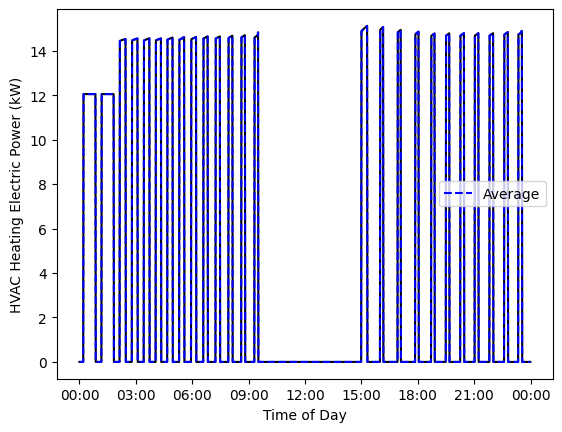

In [6]:
fig = CreateFigures.plot_daily_profile(df, 'HVAC Heating Electric Power (kW)', 
                                       plot_max=False, plot_min=False)

<Axes: xlabel='Time'>

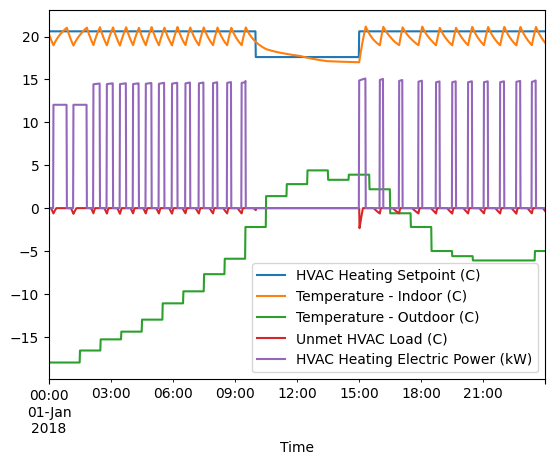

In [7]:
cols_to_plot = [
    "HVAC Heating Setpoint (C)",
    "Temperature - Indoor (C)",
    "Temperature - Outdoor (C)",
    "Unmet HVAC Load (C)",
    "HVAC Heating Electric Power (kW)",
]
df.loc[:, cols_to_plot].plot()

## Create training dataset
This portion will segment data to be trained on. This represents the "real" 
homes data. 

Input the number of training days you want.

In [8]:
train_days = 30

dwelling_args.update({
    "start_time": dt.datetime(2018, 1, 1, 0, 0),
    "duration": dt.timedelta(days=45),
    "verbosity": 9
    }
)

# Create Dwelling model
dwelling_train = Dwelling(**dwelling_args)
heater = dwelling_train.get_equipment_by_end_use("HVAC Heating")
schedule = heater.schedule
schedule["HVAC Heating Deadband (C)"] = 2
peak_times = (schedule.index.hour >= 10) & (schedule.index.hour < 15)
schedule.loc[peak_times, "HVAC Heating Setpoint (C)"] -= 3

heater.min_on_time = 600 * 2  # min cycle on for 
heater.min_off_time = 600 * 2  # min cycle off for

heater.reset_time()

df_train, metrics_train, hourly_train = dwelling_train.simulate()

2025-11-04 10:34:26.351072 - ochre at 2018-01-01 00:00:00: Initializing ochre (OCHRE v0.9.1)
2025-11-04 10:34:26.351427 - ochre at 2018-01-01 00:00:00: Removing previous results file: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre.csv
2025-11-04 10:34:26.356216 - ochre at 2018-01-01 00:00:00: Removing previous results file: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_metrics.csv
2025-11-04 10:34:26.356378 - ochre at 2018-01-01 00:00:00: Removing previous results file: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_hourly.csv
2025-11-04 10:34:30.180475 - ochre at 2018-01-01 00:00:00: Saved schedule to: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_schedule.csv
2025-11-04 10:34:30.642938 - ochre at 2018-01-01 00:00:00: Dwelling Initialized
2025-11-04 10:34:30.676734 - ochre at 2018-01-01 00:00:00: Running Simulation for 45 days, 0:00:00
2025-11-04 10:35:00.86797

In [9]:
df_train_with_weather = attach_epw_to_df(df_train, 
                                         dwelling_args["weather_file"])

In [10]:
df_train.head()

,Total Electric Power (kW),Total Reactive Power (kVAR),Total Gas Power (therms/hour),Total Electric Energy (kWh),Total Reactive Energy (kVARh),Total Gas Energy (therms),HVAC Cooling Electric Power (kW),Lighting Electric Power (kW),Water Heating Electric Power (kW),Other Electric Power (kW),...,Garage Furniture Garage Film Coefficient (m^2-K/W),Attic Wall Attic LWR Gain (W),Attic Wall Attic Surface Temperature (C),Attic Wall Attic Film Coefficient (m^2-K/W),Attic Roof Attic LWR Gain (W),Attic Roof Attic Surface Temperature (C),Attic Roof Attic Film Coefficient (m^2-K/W),Attic Floor Attic LWR Gain (W),Attic Floor Attic Surface Temperature (C),Attic Floor Attic Film Coefficient (m^2-K/W)
Time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,0.29796,0.187849,0.0,0.004966,0.003131,0.0,0.05,0.016273,0.001,0.230687,...,0.325486,22.309686,-16.256040,0.325486,206.911467,-16.386411,0.536264,-229.221153,-15.255291,0.561134
2018-01-01 00:01:00,0.29796,0.187849,0.0,0.004966,0.003131,0.0,0.05,0.016273,0.001,0.230687,...,0.325486,20.571307,-16.233508,0.325486,189.203949,-16.349772,0.536264,-209.775257,-15.314849,0.561134
2018-01-01 00:02:00,0.29796,0.187849,0.0,0.004966,0.003131,0.0,0.05,0.016273,0.001,0.230687,...,0.325486,20.527204,-16.235591,0.325486,189.397536,-16.353086,0.536264,-209.924739,-15.317247,0.561134
2018-01-01 00:03:00,0.29796,0.187849,0.0,0.004966,0.003131,0.0,0.05,0.016273,0.001,0.230687,...,0.325486,20.439605,-16.239104,0.325486,187.824788,-16.354216,0.536264,-208.264393,-15.326690,0.561134
2018-01-01 00:04:00,0.29796,0.187849,0.0,0.004966,0.003131,0.0,0.05,0.016273,0.001,0.230687,...,0.325486,20.227603,-16.247370,0.325486,186.303508,-16.362352,0.536264,-206.531110,-15.343128,0.561134


In [11]:
df_train_with_weather.head()

,Total Electric Power (kW),Total Reactive Power (kVAR),Total Gas Power (therms/hour),Total Electric Energy (kWh),Total Reactive Energy (kVARh),Total Gas Energy (therms),HVAC Cooling Electric Power (kW),Lighting Electric Power (kW),Water Heating Electric Power (kW),Other Electric Power (kW),...,Attic Roof Attic LWR Gain (W),Attic Roof Attic Surface Temperature (C),Attic Roof Attic Film Coefficient (m^2-K/W),Attic Floor Attic LWR Gain (W),Attic Floor Attic Surface Temperature (C),Attic Floor Attic Film Coefficient (m^2-K/W),Temperature - Outdoor (C) [EPW],Relative Humidity - Outdoor (%) [EPW],Global Horizontal Irradiance (W/m^2) [EPW],Wind Speed - Outdoor (m/s) [EPW]
Time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,0.29796,0.187849,0.0,0.004966,0.003131,0.0,0.05,0.016273,0.001,0.230687,...,206.911467,-16.386411,0.536264,-229.221153,-15.255291,0.561134,-18.0,85.0,0.0,0.0
2018-01-01 00:01:00,0.29796,0.187849,0.0,0.004966,0.003131,0.0,0.05,0.016273,0.001,0.230687,...,189.203949,-16.349772,0.536264,-209.775257,-15.314849,0.561134,-18.0,85.0,0.0,0.0
2018-01-01 00:02:00,0.29796,0.187849,0.0,0.004966,0.003131,0.0,0.05,0.016273,0.001,0.230687,...,189.397536,-16.353086,0.536264,-209.924739,-15.317247,0.561134,-18.0,85.0,0.0,0.0
2018-01-01 00:03:00,0.29796,0.187849,0.0,0.004966,0.003131,0.0,0.05,0.016273,0.001,0.230687,...,187.824788,-16.354216,0.536264,-208.264393,-15.326690,0.561134,-18.0,85.0,0.0,0.0
2018-01-01 00:04:00,0.29796,0.187849,0.0,0.004966,0.003131,0.0,0.05,0.016273,0.001,0.230687,...,186.303508,-16.362352,0.536264,-206.531110,-15.343128,0.561134,-18.0,85.0,0.0,0.0


Isolate the training data-set needed for envelope training.

In [12]:
df_envelope_train = df_train_with_weather[["HVAC Heating Electric Power (kW)", 
                              "HVAC Heating ER Power (kW)", 
                              "HVAC Heating Fan Power (kW)",
                              "HVAC Heating Delivered (W)",
                              "HVAC Heating Setpoint (C)",
                              "HVAC Cooling Setpoint (C)",
                              "HVAC Cooling Electric Power (kW)",
                              "HVAC Cooling Delivered (W)",
                              "Temperature - Indoor (C)", 
                              "Relative Humidity - Indoor (-)", 
                              "Temperature - Outdoor (C)",
                              "Temperature - Outdoor (C) [EPW]", 
                              "Global Horizontal Irradiance (W/m^2) [EPW]",
                              "Relative Humidity - Outdoor (%) [EPW]",
                              "Wind Speed - Outdoor (m/s) [EPW]"]]


In [13]:
df_envelope_train_1min = df_envelope_train
df_envelope_train.head()
#df_envelope_train["Temperature - Outdoor (C) [EPW]"].plot()

,HVAC Heating Electric Power (kW),HVAC Heating ER Power (kW),HVAC Heating Fan Power (kW),HVAC Heating Delivered (W),HVAC Heating Setpoint (C),HVAC Cooling Setpoint (C),HVAC Cooling Electric Power (kW),HVAC Cooling Delivered (W),Temperature - Indoor (C),Relative Humidity - Indoor (-),Temperature - Outdoor (C),Temperature - Outdoor (C) [EPW],Global Horizontal Irradiance (W/m^2) [EPW],Relative Humidity - Outdoor (%) [EPW],Wind Speed - Outdoor (m/s) [EPW]
Time,,,,,,,,,,,,,,,
2018-01-01 00:00:00,0.0,0.0,0.0,0.0,20.611111,21.611111,0.05,0.0,20.293399,0.045400,-18.0,-18.0,0.0,85.0,0.0
2018-01-01 00:01:00,0.0,0.0,0.0,0.0,20.611111,21.611111,0.05,0.0,20.176147,0.044934,-18.0,-18.0,0.0,85.0,0.0
2018-01-01 00:02:00,0.0,0.0,0.0,0.0,20.611111,21.611111,0.05,0.0,20.062137,0.045278,-18.0,-18.0,0.0,85.0,0.0
2018-01-01 00:03:00,0.0,0.0,0.0,0.0,20.611111,21.611111,0.05,0.0,19.951233,0.045616,-18.0,-18.0,0.0,85.0,0.0
2018-01-01 00:04:00,0.0,0.0,0.0,0.0,20.611111,21.611111,0.05,0.0,19.843309,0.045949,-18.0,-18.0,0.0,85.0,0.0


## Training dataset is ready to use
Training dataset is prepared. You can further exclude other variables to 
better represent the available measurements in a home. For example, it is 
unlikely to get the total heat delivered and total cooling delivered. You 
will likely only have power measurements, or indicators that the unit is on 
or off.

In the training dataset, there is:
HVAC power (including resistance heat) (kW), HVAC Heating ER Power (kW), HVAC 
Fan power (kW), HVAC Heating delivered (W), Indoor zone temperature (C), Indoor 
relative humidity (-),  Outdoor temperature (C), Outdoor relative humidity (-), 
Global horizontal irradiance (W/m^2), and Outdoor wind speed (m/s)

dataframe: df_envelope_train

Choose what time-step you would like for training

In [14]:
timestep_train = 60 #minutes
dt_train = timestep_train/60 #convert to hours
df_envelope_train = df_envelope_train.resample(f'{timestep_train}min').mean()

In [15]:
df_envelope_train.head()
#df_envelope_train["Temperature - Indoor (C)"].plot()

,HVAC Heating Electric Power (kW),HVAC Heating ER Power (kW),HVAC Heating Fan Power (kW),HVAC Heating Delivered (W),HVAC Heating Setpoint (C),HVAC Cooling Setpoint (C),HVAC Cooling Electric Power (kW),HVAC Cooling Delivered (W),Temperature - Indoor (C),Relative Humidity - Indoor (-),Temperature - Outdoor (C),Temperature - Outdoor (C) [EPW],Global Horizontal Irradiance (W/m^2) [EPW],Relative Humidity - Outdoor (%) [EPW],Wind Speed - Outdoor (m/s) [EPW]
Time,,,,,,,,,,,,,,,
2018-01-01 00:00:00,7.830684,7.607848,0.222836,6077.368712,20.611111,21.611111,0.05,0.0,20.102101,0.045899,-18.00,-18.0,0.0,85.0,0.0
2018-01-01 01:00:00,7.830684,7.607848,0.222836,6077.368712,20.611111,21.611111,0.05,0.0,20.073031,0.047425,-17.30,-18.0,0.0,85.0,0.0
2018-01-01 02:00:00,7.485723,6.047263,0.177126,6389.858965,20.611111,21.611111,0.05,0.0,19.886070,0.049613,-15.95,-16.6,0.0,83.0,0.0
2018-01-01 03:00:00,5.806498,4.681752,0.137130,4987.988892,20.611111,21.611111,0.05,0.0,20.128518,0.050766,-14.85,-15.3,0.0,85.0,0.0
2018-01-01 04:00:00,8.232226,6.632483,0.194268,7125.200512,20.611111,21.611111,0.05,0.0,19.996243,0.053519,-13.70,-14.4,0.0,90.0,0.0


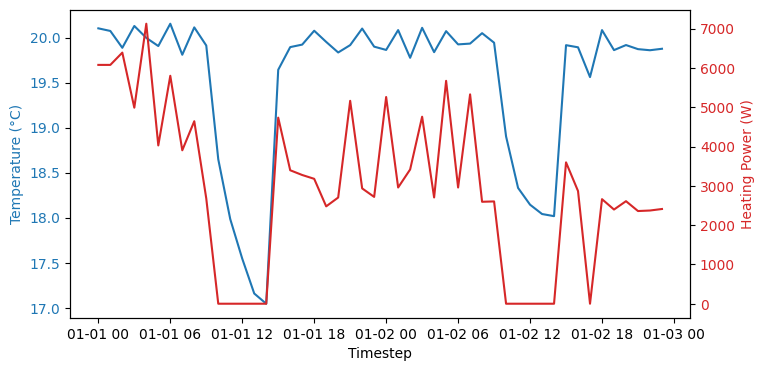

In [16]:
t_end = int(48/dt_train)
#t_end = 1440
fig, ax1 = plt.subplots(figsize=(8, 4))
# Plot Indoor Temperature on the left y-axis
color1 = 'tab:blue'
ax1.plot(df_envelope_train["Temperature - Indoor (C)"].iloc[0:t_end],
         color=color1, label='Indoor Temperature (°C)')
ax1.set_xlabel('Timestep')
ax1.set_ylabel('Temperature (°C)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()

# Plot Heating Power on the right y-axis
color2 = 'tab:red'
ax2.plot(df_envelope_train["HVAC Heating Delivered (W)"].iloc[0:t_end],
         color=color2, label='HVAC Heating Delivered (W)')
ax2.set_ylabel('Heating Power (W)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.show()


## Implement Hankel Predictor

RC training used as an example

In [17]:
df_heating_annual_night = df_envelope_train.copy()
df_heating_annual_night['Hour'] = df_envelope_train.index.hour

# Define night and day conditions
# Condition 1: Time is between 10 PM and 6 AM
night_time_condition = (df_heating_annual_night['Hour'] >= 20) | \
                       (df_heating_annual_night['Hour'] < 6)

# Condition 2: Solar Irradiation is 0 (assuming 'SolarRadiation' is the correct column name)
if 'Global Horizontal Irradiance (W/m^2) [EPW]' in df_heating_annual_night.columns:
    night_solar_condition = (df_heating_annual_night['Global Horizontal Irradiance (W/m^2) [EPW]'] == 0)
    df_heating_annual_night['is_night'] = night_time_condition & night_solar_condition
else:
    print("\nWarning: 'Global Horizontal Irradiance (W/m^2) [EPW]' column not found after preprocessing. Cannot use it for night/day split.")
    df_heating_annual_night['is_night'] = night_time_condition # Fallback to just time condition

df_heating_annual_night['is_night']

Time
2018-01-01 00:00:00     True
2018-01-01 01:00:00     True
2018-01-01 02:00:00     True
2018-01-01 03:00:00     True
2018-01-01 04:00:00     True
                       ...  
2018-02-14 19:00:00    False
2018-02-14 20:00:00     True
2018-02-14 21:00:00     True
2018-02-14 22:00:00     True
2018-02-14 23:00:00     True
Freq: 60min, Name: is_night, Length: 1080, dtype: bool

In [18]:
boolean_night = df_heating_annual_night['is_night'].astype(int)
boolean_night

Time
2018-01-01 00:00:00    1
2018-01-01 01:00:00    1
2018-01-01 02:00:00    1
2018-01-01 03:00:00    1
2018-01-01 04:00:00    1
                      ..
2018-02-14 19:00:00    0
2018-02-14 20:00:00    1
2018-02-14 21:00:00    1
2018-02-14 22:00:00    1
2018-02-14 23:00:00    1
Freq: 60min, Name: is_night, Length: 1080, dtype: int64

In [ ]:
T_in_1min = df_envelope_train_1min["Temperature - Indoor (C)"]
T_in_first = T_in_1min.resample(f'{timestep_train}min').first()
T_in_diff = np.diff(T_in_first)

T_in = df_envelope_train["Temperature - Indoor (C)"].to_numpy()
Y = np.diff(T_in) / float(dt_train)
#Y = T_in_diff / float(dt_train)  

X1 = df_envelope_train["HVAC Heating Delivered (W)"].to_numpy()[:-1] / 1000.0
X2 = (df_envelope_train["Temperature - Outdoor (C)"].to_numpy()
      - df_envelope_train["Temperature - Indoor (C)"].to_numpy())[:-1]
X3 = df_envelope_train["Global Horizontal Irradiance (W/m^2) [EPW]"].to_numpy()[
     :-1] / 1000.0
X = np.column_stack((X1, X2, X3))  #, X4))

In [19]:

plt.plot(np.diff(T_in), label='np.diff')
plt.plot(T_in_diff, label='diff_start')
plt.legend()
plt.show()

In [20]:
'''
T_in = df_envelope_train["Temperature - Indoor (C)"].to_numpy()
Y = np.diff(T_in) / float(dt_train)  

X1 = df_envelope_train["HVAC Heating Delivered (W)"].to_numpy()[:-1] / 1000.0
X2 = (df_envelope_train["Temperature - Outdoor (C)"].to_numpy()
      - df_envelope_train["Temperature - Indoor (C)"].to_numpy())[:-1]
X3 = np.ones_like(X2)
X = np.column_stack((X1, X2, X3))
'''

'\nT_in = df_envelope_train["Temperature - Indoor (C)"].to_numpy()\nY = np.diff(T_in) / float(dt_train)  \n\nX1 = df_envelope_train["HVAC Heating Delivered (W)"].to_numpy()[:-1] / 1000.0\nX2 = (df_envelope_train["Temperature - Outdoor (C)"].to_numpy()\n      - df_envelope_train["Temperature - Indoor (C)"].to_numpy())[:-1]\nX3 = np.ones_like(X2)\nX = np.column_stack((X1, X2, X3))\n'

In [21]:
def hankel_matrix(data,L):
    """
    Construct a block Hankel matrix of depth L from time-series data.

    Parameters
    ----------
    data : np.ndarray, shape (T, d)
        The time series (each row is a timestep, each column a variable).
    L : int
        The number of block rows (window length).

    Returns
    -------
    H : np.ndarray, shape (L*d, T - L + 1)
        The block Hankel matrix.
    d : the corresponding channels for the data 
    """
    data_new = np.atleast_2d(data)
    if data_new.shape[0] == 1:
        data = data_new.T
    
    T,d = data.shape
    cols = T-L+1
    H = np.zeros((L*d,cols))
    for i in range(L):
        H[i*d:(i+1)*d, :] = data[i:i+cols, :].T
    return H,d

In [39]:
# -----Tunable parameters------
# T_ini - number of days in window
n_days = 1

In [40]:
# --- Choose horizons ----------------------------------
T_ini = int(n_days*24/dt_train)      # past window length
N = 24          # prediction horizon
L = T_ini + N   # total Hankel depth

In [41]:
# Split raw time series first (avoid overlapping columns across sets)
T_total = len(X)
T_train = int(14*24/dt_train) # in days

X_train, Y_train = X[:T_train], Y[:T_train]
X_test,  Y_test  = X[T_train - (L-1):], Y[T_train - (L-1):]  

U_H_tr,m = hankel_matrix(X_train, L)
Y_H_tr,p = hankel_matrix(Y_train, L)

U_H_te,m = hankel_matrix(X_test, L)
Y_H_te,p = hankel_matrix(Y_test, L)

# Partition into past/future block rows
U_p_tr = U_H_tr[:T_ini * m, :]
U_f_tr = U_H_tr[T_ini * m:, :]
Y_p_tr = Y_H_tr[:T_ini * p, :]
Y_f_tr = Y_H_tr[T_ini * p:, :]

U_p_te = U_H_te[:T_ini * m, :]
U_f_te = U_H_te[T_ini * m:, :]
Y_p_te = Y_H_te[:T_ini * p, :]
Y_f_te = Y_H_te[T_ini * p:, :]



In [42]:
# Pick a test column k
k = U_H_te.shape[1] - 1
u_ini = U_H_te[:T_ini*m, [k]]
y_ini = Y_H_te[:T_ini*p, [k]]
u = U_H_te[T_ini*m:, [k]]
y = Y_H_te[T_ini*p:, [k]]  # ground truth

# Solve with *train* columns only
H_tr = np.vstack([U_p_tr, Y_p_tr, U_f_tr])
rhs  = np.vstack([u_ini, y_ini, u]).ravel()

lam = 1e-6
g = np.linalg.solve(H_tr.T @ H_tr + lam*np.eye(H_tr.shape[1]), H_tr.T @ rhs)
y_diff_pred = (Y_f_tr @ g).reshape(N, p)
y_diff_true = y.reshape(N, p)

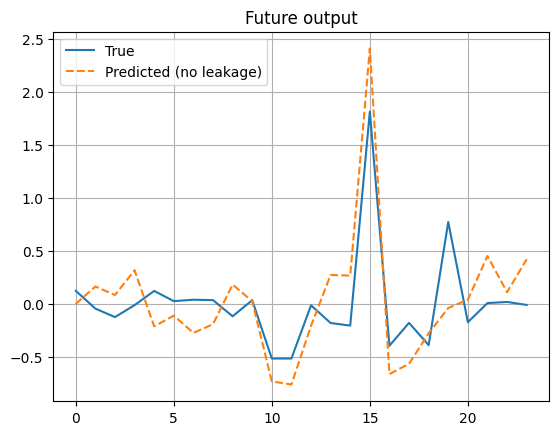

RMSE per output: [0.34452092]


In [43]:
t = np.arange(N)
plt.plot(t, y_diff_true, label="True")
plt.plot(t, y_diff_pred, "--", label="Predicted (no leakage)")
plt.legend(); plt.grid(True); plt.title("Future output"); plt.show()

rmse = np.sqrt(np.mean((y_diff_pred - y_diff_true)**2, axis=0))
print("RMSE per output:", rmse)
                # true future output


## Hankel Predictor Offline

In [79]:
steps_per_day = N  # assuming N = 24 = 24 hours
num_days = 7

T_test = len(Y_test)

# Choose the start of the 14-day evaluation window in the *test* set
t0_first = T_test - num_days * steps_per_day


=== 14-Day Daily Hankel Forecast Analysis ===
Mean RMSE on dT/dt over 14 days: 0.5254 [°C/time-unit]
Mean RMSE on T over 14 days:    0.5208 [°C]
Per-day RMSE on T [°C]:
  Day  1: 0.6771
  Day  2: 0.5213
  Day  3: 0.5866
  Day  4: 0.4544
  Day  5: 0.6053
  Day  6: 0.4171
  Day  7: 0.3838


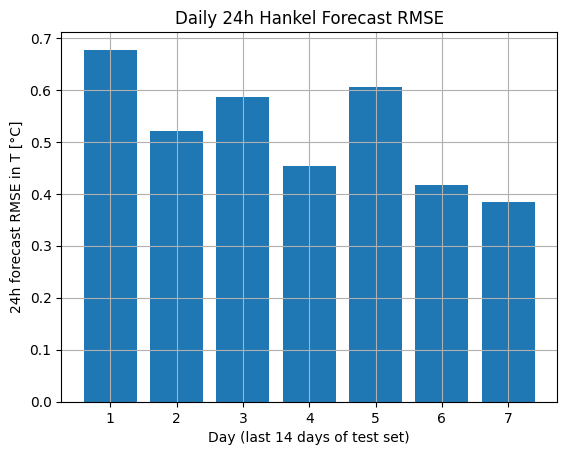

In [80]:

if t0_first - T_ini < 0:
    raise ValueError(
        "Not enough past data in test set for 14-day Hankel analysis. "
        "Reduce num_days or T_ini.")

rmse_y_days = []  # RMSE per day on dT/dt
rmse_T_days = []  # RMSE per day on indoor temperature

# Store per-step temperature errors (shape: num_days x (steps_per_day+1))
temp_err_all = np.zeros((num_days, steps_per_day + 1))
T_true_all = np.zeros((num_days, steps_per_day + 1))
T_pred_all = np.zeros((num_days, steps_per_day + 1))

for d in range(num_days):
    # Index in Y_test where this day's 24h prediction starts
    t0_te = t0_first + d * steps_per_day  # index into Y_test

    # Corresponding Hankel column index in U_H_te / Y_H_te
    # Column j uses data Y_test[j : j + L], so the future starts at j + T_ini.
    # We want future to start at t0_te -> j = t0_te - T_ini
    k_col = t0_te - T_ini

    # Sanity check: ensure this column is valid
    if k_col < 0 or k_col >= U_H_te.shape[1]:
        raise IndexError(f"Invalid Hankel column index {k_col} for day {d}.")

    # Extract past/future blocks for this specific day from the *test* Hankel
    u_p_te_d = U_H_te[:T_ini * m, [k_col]]
    y_p_te_d = Y_H_te[:T_ini * p, [k_col]]
    u_f_te_d = U_H_te[T_ini * m:, [k_col]]
    y_f_te_d = Y_H_te[T_ini * p:, [k_col]]  # ground-truth dT/dt over horizon

    # Right-hand side for this day's trajectory
    rhs_d = np.vstack([u_p_te_d, y_p_te_d, u_f_te_d]).ravel()

    # Solve for g_d using noise with lam
    #g_d = np.linalg.solve(
    #    H_tr.T @ H_tr + lam * np.eye(H_tr.shape[1]),
    #    H_tr.T @ rhs_d
    #)
    # noise free:
    g_d, *_ = np.linalg.lstsq(H_tr, rhs_d, rcond=None)

    # Predict future dT/dt using training Y_f_tr and the new g_d
    y_diff_pred_d = (Y_f_tr @ g_d).reshape(N, p)
    y_diff_true_d = y_f_te_d.reshape(N, p)

    # RMSE on dT/dt for this day (scalar, since p=1)
    rmse_y = np.sqrt(np.mean((y_diff_pred_d - y_diff_true_d) ** 2))
    rmse_y_days.append(rmse_y)

    # --- Reconstruct indoor temperature trajectories for interpretability ---
    # Map index t0_te in Y_test back to global index in Y (and T_in)
    # Recall: Y_test = Y[T_train - (L-1):]
    t0_global = (T_train - (L - 1)) + t0_te

    # Starting indoor temperature at the forecast start
    T0 = T_in[t0_global]

    # True indoor temperatures for this day: length steps_per_day+1
    T_true_d = T_in[t0_global: t0_global + steps_per_day + 1]

    if len(T_true_d) < steps_per_day + 1:
        raise ValueError(
            f"Not enough T_in samples to build true 24h trajectory for day {d}.")

    # Forward Euler reconstruction from predicted dT/dt
    T_pred_d = np.empty_like(T_true_d)
    T_pred_d[0] = T0
    for k_step in range(steps_per_day):
        # Y = dT/dt, so ΔT = dt_train * Y
        T_pred_d[k_step + 1] = T_pred_d[k_step] + dt_train * y_diff_pred_d[
            k_step, 0]
    
        # Save trajectories for plotting later
    T_true_all[d, :] = T_true_d
    T_pred_all[d, :] = T_pred_d
    # RMSE on temperature for this day
    rmse_T = np.sqrt(np.mean((T_pred_d - T_true_d) ** 2))
    rmse_T_days.append(rmse_T)

    # Store error trajectory (predicted minus true)
    temp_err_all[d, :] = T_pred_d - T_true_d

rmse_y_days = np.array(rmse_y_days)
rmse_T_days = np.array(rmse_T_days)

print("=== 14-Day Daily Hankel Forecast Analysis ===")
print(
    f"Mean RMSE on dT/dt over 14 days: {rmse_y_days.mean():.4f} [°C/time-unit]")
print(f"Mean RMSE on T over 14 days:    {rmse_T_days.mean():.4f} [°C]")
print("Per-day RMSE on T [°C]:")
for d, val in enumerate(rmse_T_days):
    print(f"  Day {d + 1:2d}: {val:.4f}")

t_hours = np.arange(steps_per_day + 1)  # interpret as hours ahead if dt_train=1

plt.figure()
plt.bar(np.arange(1, num_days + 1), rmse_T_days)
plt.xlabel("Day (last 14 days of test set)")
plt.ylabel("24h forecast RMSE in T [°C]")
plt.title("Daily 24h Hankel Forecast RMSE")
plt.grid(True)



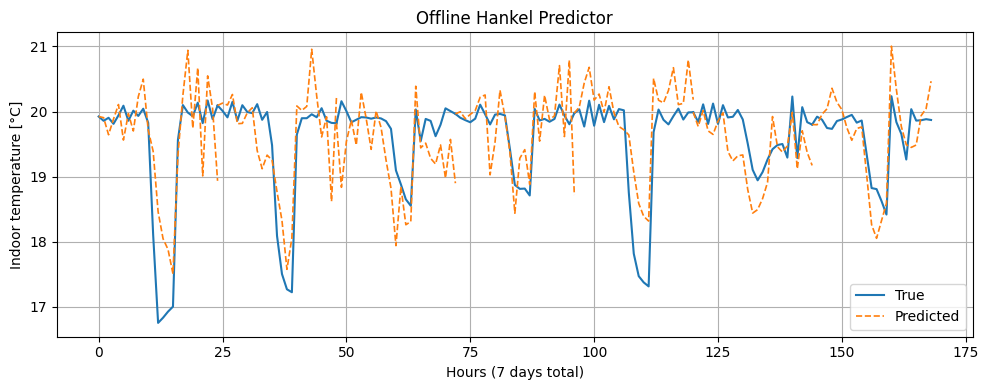

In [82]:
# === Continuous 14-day plot of predicted vs true indoor temperature ===
t_hours_day = np.arange(steps_per_day + 1)  # local (0–24 h)
t_hours_full = np.arange((steps_per_day + 1) * num_days) * dt_train  # total time span in hours

plt.figure(figsize=(10, 4))

for d in range(num_days):
    # compute time offset for this day in hours
    t_offset = d * steps_per_day * dt_train
    t_global = t_hours_day * dt_train + t_offset

    # plot true and predicted for this day in continuous time
    plt.plot(t_global, T_true_all[d, :], color="tab:blue", linewidth=1.5)
    plt.plot(t_global, T_pred_all[d, :], "--", color="tab:orange", linewidth=1.2)

# Labels and legend (only one legend entry)
plt.xlabel("Hours (7 days total)")
plt.ylabel("Indoor temperature [°C]")
plt.title("Offline Hankel Predictor")
plt.legend(["True", "Predicted"], loc="best")
plt.grid(True)
plt.tight_layout()
plt.savefig('offline_hankel.png')
plt.show()



# Adaptive Hankel Predictor (online approach)

In [73]:

steps_per_day = N  # assuming N = 24 = 24 hours
num_days = 7

T_test = len(Y_test)

# Choose the start of the 14-day evaluation window in the *test* set
t0_first = T_test - num_days * steps_per_day

if t0_first - T_ini < 0:
    raise ValueError(
        "Not enough past data in test set for 14-day Hankel analysis. "
        "Reduce num_days or T_ini.")

In [74]:
X_adapt, Y_adapt = X[:T_train+t0_first], Y[:T_train+t0_first]
U_H_adapt,m = hankel_matrix(X_adapt, L)
Y_H_adapt,p = hankel_matrix(Y_adapt, L)

U_H_adapt_p = U_H_adapt[:T_ini * m, :]
U_H_adapt_f = U_H_adapt[T_ini * m:, :]
Y_H_adapt_p = Y_H_adapt[:T_ini * p, :]
Y_H_adapt_f = Y_H_adapt[T_ini * p:, :]

=== 14-Day Daily Hankel Forecast Analysis ===
Mean RMSE on dT/dt over 14 days: 0.1919 [°C/time-unit]
Mean RMSE on T over 14 days:    0.2364 [°C]
Per-day RMSE on T [°C]:
  Day  1: 0.2441
  Day  2: 0.2041
  Day  3: 0.2165
  Day  4: 0.1739
  Day  5: 0.2553
  Day  6: 0.3127
  Day  7: 0.2479


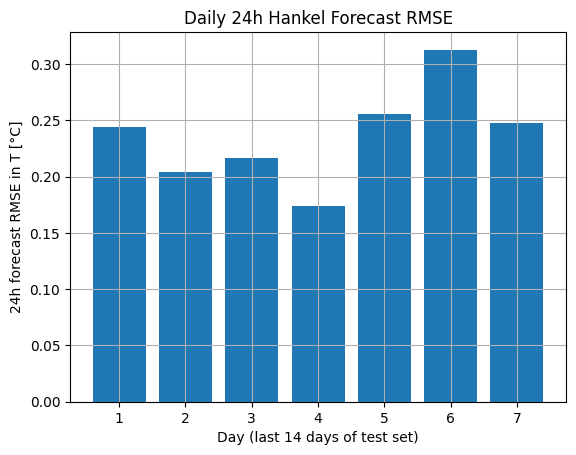

In [83]:

rmse_y_days = []  # RMSE per day on dT/dt
rmse_T_days = []  # RMSE per day on indoor temperature

# Store per-step temperature errors (shape: num_days x (steps_per_day+1))
temp_err_all = np.zeros((num_days, steps_per_day + 1))
T_true_all = np.zeros((num_days, steps_per_day + 1))
T_pred_all = np.zeros((num_days, steps_per_day + 1))

for d in range(num_days):
    # Index in Y_test where this day's 24h prediction starts
    t0_te = t0_first + d * steps_per_day  # index into Y_test
    
    # Redefine hankel to to have latest data
    X_adapt, Y_adapt = X[:T_train+t0_te], Y[:T_train+t0_te]
    U_H_adapt,m = hankel_matrix(X_adapt, L)
    Y_H_adapt,p = hankel_matrix(Y_adapt, L)
    
    U_H_adapt_p = U_H_adapt[:T_ini * m, :]
    U_H_adapt_f = U_H_adapt[T_ini * m:, :]
    Y_H_adapt_p = Y_H_adapt[:T_ini * p, :]
    Y_H_adapt_f = Y_H_adapt[T_ini * p:, :]
    
    H_tr_adapt = np.vstack([U_H_adapt_p, Y_H_adapt_p, U_H_adapt_f])
    
    # Corresponding Hankel column index in U_H_te / Y_H_te
    # Column j uses data Y_test[j : j + L], so the future starts at j + T_ini.
    # We want future to start at t0_te -> j = t0_te - T_ini
    k_col = t0_te - T_ini

    # Sanity check: ensure this column is valid
    if k_col < 0 or k_col >= U_H_te.shape[1]:
        raise IndexError(f"Invalid Hankel column index {k_col} for day {d}.")

    # Extract past/future blocks for this specific day from the *test* Hankel
    u_p_te_d = U_H_te[:T_ini * m, [k_col]]
    y_p_te_d = Y_H_te[:T_ini * p, [k_col]]
    u_f_te_d = U_H_te[T_ini * m:, [k_col]]
    y_f_te_d = Y_H_te[T_ini * p:, [k_col]]  # ground-truth dT/dt over horizon

    # Right-hand side for this day's trajectory
    rhs_d = np.vstack([u_p_te_d, y_p_te_d, u_f_te_d]).ravel()

    # Solve for g_d using noise with lam
    #g_d = np.linalg.solve(
    #    H_tr_adapt.T @ H_tr_adapt + lam * np.eye(H_tr_adapt.shape[1]),
    #    H_tr_adapt.T @ rhs_d
    #)
    # noise free:
    g_d, *_ = np.linalg.lstsq(H_tr_adapt, rhs_d, rcond=None)
    # Predict future dT/dt using training Y_f_tr and the new g_d
    y_diff_pred_d = (Y_H_adapt_f @ g_d).reshape(N, p)
    y_diff_true_d = y_f_te_d.reshape(N, p)

    # RMSE on dT/dt for this day (scalar, since p=1)
    rmse_y = np.sqrt(np.mean((y_diff_pred_d - y_diff_true_d) ** 2))
    rmse_y_days.append(rmse_y)

    # --- Reconstruct indoor temperature trajectories for interpretability ---
    # Map index t0_te in Y_test back to global index in Y (and T_in)
    # Recall: Y_test = Y[T_train - (L-1):]
    t0_global = (T_train - (L - 1)) + t0_te

    # Starting indoor temperature at the forecast start
    T0 = T_in[t0_global]

    # True indoor temperatures for this day: length steps_per_day+1
    T_true_d = T_in[t0_global: t0_global + steps_per_day + 1]

    if len(T_true_d) < steps_per_day + 1:
        raise ValueError(
            f"Not enough T_in samples to build true 24h trajectory for day {d}.")

    # Forward Euler reconstruction from predicted dT/dt
    T_pred_d = np.empty_like(T_true_d)
    T_pred_d[0] = T0
    for k_step in range(steps_per_day):
        # Y = dT/dt, so ΔT = dt_train * Y
        T_pred_d[k_step + 1] = T_pred_d[k_step] + dt_train * y_diff_pred_d[
            k_step, 0]

        # Save trajectories for plotting later
    T_true_all[d, :] = T_true_d
    T_pred_all[d, :] = T_pred_d
    # RMSE on temperature for this day
    rmse_T = np.sqrt(np.mean((T_pred_d - T_true_d) ** 2))
    rmse_T_days.append(rmse_T)

    # Store error trajectory (predicted minus true)
    temp_err_all[d, :] = T_pred_d - T_true_d

rmse_y_days = np.array(rmse_y_days)
rmse_T_days = np.array(rmse_T_days)

print("=== 14-Day Daily Hankel Forecast Analysis ===")
print(
    f"Mean RMSE on dT/dt over 14 days: {rmse_y_days.mean():.4f} [°C/time-unit]")
print(f"Mean RMSE on T over 14 days:    {rmse_T_days.mean():.4f} [°C]")
print("Per-day RMSE on T [°C]:")
for d, val in enumerate(rmse_T_days):
    print(f"  Day {d + 1:2d}: {val:.4f}")

t_hours = np.arange(steps_per_day + 1)  # interpret as hours ahead if dt_train=1

plt.figure()
plt.bar(np.arange(1, num_days + 1), rmse_T_days)
plt.xlabel("Day (last 14 days of test set)")
plt.ylabel("24h forecast RMSE in T [°C]")
plt.title("Daily 24h Hankel Forecast RMSE")
plt.grid(True)

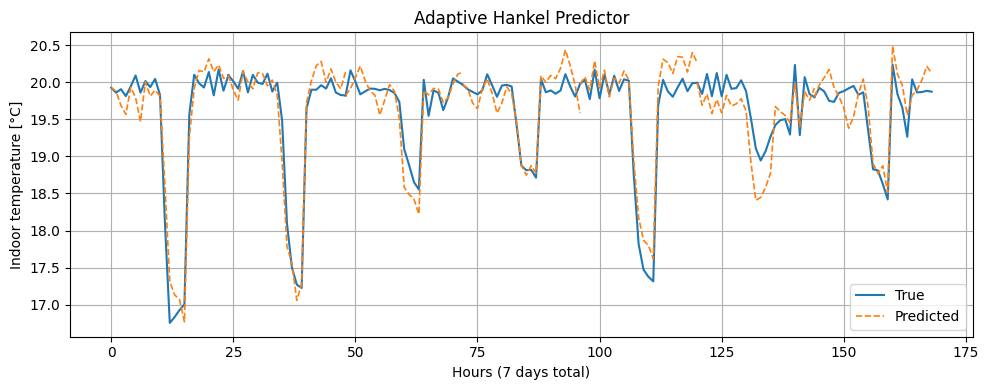

In [84]:

# === Continuous 14-day plot of predicted vs true indoor temperature ===
t_hours_day = np.arange(steps_per_day + 1)  # local (0–24 h)
t_hours_full = np.arange(
    (steps_per_day + 1) * num_days) * dt_train  # total time span in hours

plt.figure(figsize=(10, 4))

for d in range(num_days):
    # compute time offset for this day in hours
    t_offset = d * steps_per_day * dt_train
    t_global = t_hours_day * dt_train + t_offset

    # plot true and predicted for this day in continuous time
    plt.plot(t_global, T_true_all[d, :], color="tab:blue", linewidth=1.5)
    plt.plot(t_global, T_pred_all[d, :], "--", color="tab:orange",
             linewidth=1.2)

# Labels and legend (only one legend entry)
plt.xlabel("Hours (7 days total)")
plt.ylabel("Indoor temperature [°C]")
plt.title("Adaptive Hankel Predictor")
plt.legend(["True", "Predicted"], loc="best")
plt.grid(True)
plt.tight_layout()
plt.savefig('online_hankel.png')
plt.show()
